#### Task.

1. Training model over 1.5 million data syth.
2. Try to use prunning to speed up training process.


# Import libraries

In [1]:
import pandas as pd
import numpy as np
import random
import os
from tqdm import tqdm
from IPython.display import clear_output

import matplotlib.pyplot as plt
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import OneCycleLR, ReduceLROnPlateau, CyclicLR, StepLR
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
import torch.nn.utils.prune as prune

# Global args

In [2]:
SEQUENCE_LENGTH = 72
N_HEADS = 6
N_LAYERS = 6


EPOCHS = 150
BATCH_SIZE = 64
NUM_WORKERS = 5

PATH_TO_TRAINING_DATA = "/home/gishb/datasets/change_points/training"
PATH_TO_VALIDATION_DATA =  "/home/gishb/datasets/change_points/validation"


PATH_TO_PRETRAINED_MODEL = '../models/LargeModelWeights/EncoderAlphaCPD.pth'

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# device = "cpu"

print(device)
print(torch.cuda.get_device_name())

cuda:0
NVIDIA GeForce RTX 3060 Laptop GPU


# Load dataset

In [3]:
class TimeSeries(Dataset):
    def __init__(self, path_to_files_dir, sequence_length_nn: int = 72):
        self.path_to_files_dir = path_to_files_dir
        self.sequence_length_nn = sequence_length_nn
        self.list_of_files = self.__load_list_of_files()

    def __load_list_of_files(self) -> list:
        return os.listdir(self.path_to_files_dir)

    def __load_data(self, idx) -> pd.DataFrame:
        return pd.read_csv(self.path_to_files_dir+"/"+self.list_of_files[idx])

    def __len__(self):
        return len(os.listdir(self.path_to_files_dir))
        
    def __getitem__(self, idx):
        try:
            dataframe = self.__load_data(idx)
            
            y = dataframe["cps"].to_numpy()
            x = dataframe["values"].to_numpy()
            
            x = self.normalize_by_minmax(x)
            
            padded_x = self.padding_sequence(x, d_model=self.sequence_length_nn)
            padded_y = self.padding_sequence(y, d_model=self.sequence_length_nn)
            
            x_prepaired = self.prepaire_sequence_to_encoding(padded_x)
            y_prepaired = self.prepaire_sequence_to_encoding(padded_y)
            return torch.Tensor(x_prepaired), torch.Tensor(y_prepaired)
        except:
            pass

    def padding_sequence(self, data: np.array, d_model: int) -> np.array:
        not_dev_count = data.shape[0] % d_model
        if not_dev_count != 0:
            val_new_rows = int(np.ceil(data.shape[0] / d_model) * d_model - data.shape[0])
            data = np.pad(data, 
                     pad_width=((0), (val_new_rows)),  # Pad val_new_rows to sequence
                     mode='constant', 
                     constant_values=data[-1])
        return data
    
    def prepaire_sequence_to_encoding(self, data) -> torch.Tensor:
        """ Take padded numpy array to preapre it to torch.Tensor for NN
        """
        number_of_words = data.shape[0] // self.sequence_length_nn
        return torch.Tensor(data).view(number_of_words, self.sequence_length_nn)
    
    def normalize_by_minmax(self, data: np.array) -> np.array:
        return (data-data.min())/(data.max()-data.min())

In [4]:
dataset_val = TimeSeries(path_to_files_dir=PATH_TO_VALIDATION_DATA)
dataset_train = TimeSeries(path_to_files_dir=PATH_TO_TRAINING_DATA)

train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(dataset_val, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)

# Define Encoder Transformer

In [5]:
class ChangesBERT(nn.Module):
    def __init__(self,
                 sequence_length: int = 72, # 36 is ok for 6 heads | 72 is ok for 6 heads (~500 epochs 1e-3->1e-4)
                 n_layers: int = 6,
                 n_heads: int = 6,
                 dim_feedforward: int = 2056):
        super().__init__()
        
        self.activation = nn.Sigmoid()
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=sequence_length,
                                                   nhead=n_heads,
                                                   dim_feedforward=dim_feedforward,
                                                   norm_first=True,
                                                   batch_first=True)
        
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
    @torch.inference_mode()
    def encode(self, x):
        """ Encode time series to a map of features.

        Arg:
            x: batch of raw time series data.
            
        Return:
            batch of encoded time series data.
        """
        return self.encoder(x)

    def forward(self, encoder_x):
        encoded_data = self.encoder(src=encoder_x)
        return self.activation(encoded_data)

#### Define Positional Encoding for time series

In [6]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout=0.1, max_len=1024, device: str = "cuda"):
        """ 
        Notes:
            d_model: number of features which reprsenet 1 token in NLP.
            max_len: length of the longest sequence which we can hold in memory by POSINCODING!
        
        Example:
            max_len 1024 means that max pos len is 1024 for time series which has 16 sequence where 
            each sequence length is 32. Like torch.Size([16, 1, 32]) # number sequences, batch, feature sequence
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1).to(torch.device(device))
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return x

# Define trainig & validation pipeline

In [7]:
def train(model, loader):
    model.train()

    train_loss = 0

    for x_en, y in tqdm(loader, desc='Training'):
        x_en, y = x_en.to(device), y.to(device)
        optimizer.zero_grad()

        output = model(encoding_pos(x_en))

        loss = loss_fn(output, y)

        train_loss += loss.item()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_loader)

    return train_loss

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()

    total_loss = 0

    for x_en, y in tqdm(loader, desc='Evaluation'):
        x_en, y = x_en.to(device), y.to(device)

        output = model(encoding_pos(x_en))

        loss = loss_fn(output, y)

        total_loss += loss.item()

    total_loss /= len(loader)

    return total_loss

def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()

    plt.show()

def whole_train_valid_cycle(model, num_epochs, title, scheduler):
    train_loss_history, valid_loss_history = [], []

    for epoch in range(num_epochs):
        train_loss = train(model, train_loader)
        valid_loss = evaluate(model, valid_loader)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        clear_output(wait=True)

        scheduler.step()

        plot_stats(
            train_loss_history, valid_loss_history,
            title
        )

# Utility to prune weights

In [8]:
def prune_model_global_unstructured(model, amount, prune_type='l1'):
    parameters_to_prune = []
    
    # Collect all parameters to prune
    for name, module in model.named_modules():
        if hasattr(module, 'weight'):
            parameters_to_prune.append((module, 'weight'))
    
    # Convert to tuple of tuples for global pruning
    parameters_to_prune = tuple(parameters_to_prune)
    
    # Select pruning method
    if prune_type.lower() == 'l1':
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.L1Unstructured,
            amount=amount
        )
    elif prune_type.lower() == 'random':
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.RandomUnstructured,
            amount=amount
        )
    else:
        raise ValueError(f"Unknown pruning type: {prune_type}")
    
    # Make pruning permanent by removing the mask and original weights
    for module, _ in parameters_to_prune:
        prune.remove(module, 'weight')
    
    return model

In [9]:
def print_sparsity(model):
    element_number_global = 0
    element_number_zero = 0
    for name, module in model.named_modules():
        if hasattr(module, 'weight'):
            # Count non-zero elements
            n_zeros = torch.sum(module.weight == 0)
            n_elements = module.weight.nelement()
            element_number_global += n_elements
            element_number_zero += n_zeros
            print(f"{name}: {n_zeros}/{n_elements} zeros ({100*n_zeros/n_elements:.2f}%)")
    print(f"Global pruning: {100*element_number_zero/element_number_global:.2f}%")

# Setting up experiment

In [10]:
model = ChangesBERT().to(device)
model.load_state_dict(torch.load(PATH_TO_PRETRAINED_MODEL, weights_only=True))

encoding_pos = PositionalEncoding(d_model=SEQUENCE_LENGTH, device=device)

/home/gishb/PycharmProjects/DirectionalDrillingChangePointDetection/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [11]:
model = prune_model_global_unstructured(model, 0.4)

In [12]:
optimizer = Adam(model.parameters(), lr=1e-6, weight_decay=0.4, foreach=False)
loss_fn = nn.BCELoss(reduction="sum")

In [13]:
scheduler = OneCycleLR(
    optimizer,
    max_lr=4e-6,  # Peak LR (can be higher than initial)
    total_steps=EPOCHS,
    pct_start=0.1,
    anneal_strategy='linear'
)

# Training and validation cycle

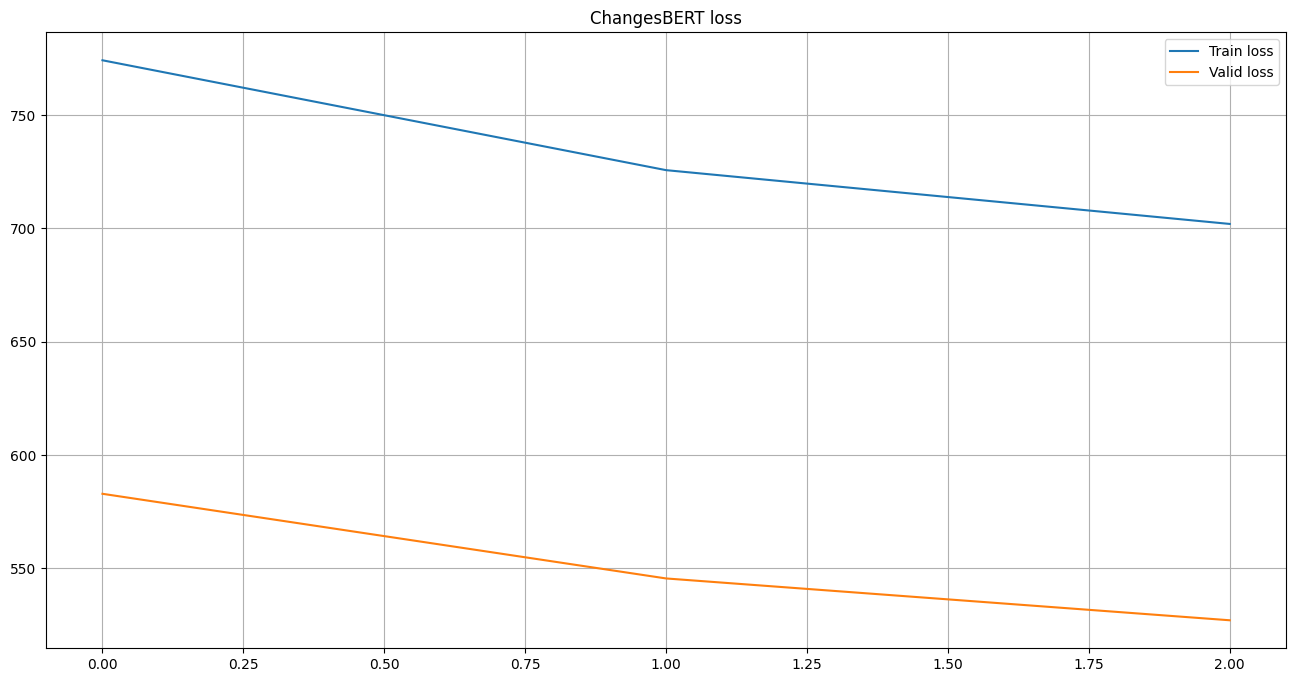

Training:   3%|████▎                                                                                                                                                              | 697/26122 [00:15<09:15, 45.78it/s]

In [ ]:
whole_train_valid_cycle(model, EPOCHS, 'ChangesBERT', scheduler)

In [ ]:
for test_x, test_y in iter(valid_loader):
    counter = 0
    for val in range(BATCH_SIZE):
        counter += 1
        
        plt.figure(figsize=(20,5))
        plt.plot(test_x[counter].flatten(), label="data")
        plt.plot(test_y[counter].flatten(), label='original')
        plt.plot(model(test_x[counter].unsqueeze(0).to(device)).flatten().to("cpu").detach(), label='predicted')
        plt.legend()
        
        if counter >= 14:
            break
    break